# The macro layer — four claims, four mechanisms, four numbers

The premium is not a company story, but "macro matters" is not a claim either. Each of the
four statements below names the mechanism it runs through and the number that sizes it. Two
are supported, one is supported and small, and one is a **registered null** — reported as a
null, because the alternative is to let an untested conditional carry a slide.

| # | claim | mechanism | number | status |
|---|---|---|---|---|
| 1 | The AI/HBM bid is what opened the gap | US demand meets a supply that cannot respond | ADR ADV **$8.8bn** on 12 sessions vs **$8.3bn** for the decade-old local line | landed |
| 2 | The trade's cost is Fed-sensitive | USD rate is *earned* on collateral and short proceeds | **2.1bp/month per 25bp**, and a hike makes it *cheaper* | landed |
| 3 | The won moves the premium's level | π is a currency-denominated ratio | **0.86 premium points per 1% KRW** (95% CI 0.65–1.06); FX is **1.3%** of daily variance | landed |
| 4 | The won selects the resolution channel | strength should favour the local leg closing the gap | **+16.5pp in the predicted direction, p = 0.25** | **registered NULL** |

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import pandas as pd
from pipeline.viz import theme, figures
from pipeline.package import capacity as CAP, financing as F
from pipeline.hedging.ratios import HedgeLegs, fx_sensitivity
from pipeline.lab import tsmc as LAB
from scripts.export_client_pack import panels
theme.apply()
PANELS = dict(panels())

## 1. The bid — demand meets a supply that cannot answer

**Mechanism.** US buyers want the exposure. Ordinarily their demand is met by creating more
ADRs, which is what keeps a fungible pair at zero. Here creation requires the Company's
consent, so demand has nowhere to go except into the price of the existing line.

**Number.** The ADR is three weeks old and already trades more than the local line does.

In [2]:
CAP.adv_table()

,leg,adv_usd,n_sessions,first,last,caveat
0,"SKHY (ADR, USD)",8.834096e+09,12,2026-07-14,2026-07-29,"3-week history: regime-fresh, not a cycle-aver..."
1,"000660 (local, KRW)",8.306548e+09,2838,2015-01-06,2026-07-29,deep history


An ADR turning over **$8.8bn a day after twelve sessions**, against **$8.3bn** for a line
with 2,838 sessions of history, is the demand side of this trade stated as a fact rather than
a narrative. The caveat travels with it and is printed in the table: twelve sessions is
regime-fresh, not a cycle-average, and a listing's first weeks are its noisiest.

**What is scheduled.** Q2 earnings sit in the event register at 2026-07-29. This notebook
does not model the memory cycle and takes no view on it — the claim is about the *shape* of
demand meeting sealed supply, not about the level of HBM pricing.

## 2. The Fed path — the cost leg, and it points the unintuitive way

In [3]:
pd.Series(F.fed_sensitivity())

shift_bp                                                                     25.0
carry_now_bp_per_year                                                       335.0
carry_after_hike_bp_per_year                                                310.0
carry_after_cut_bp_per_year                                                 360.0
bp_per_month_per_25bp                                                        2.08
direction                       A HIKE REDUCES the cost of holding this trade ...
caveat                          Assumes the KRW leg and the borrow spread are ...
dtype: object

**Mechanism.** The client posts USD collateral and the ADR short generates USD proceeds. Both
*earn* the USD rate. The KRW funding leg pays the Korean rate. So the USD rate enters the
carry with a negative sign.

**Number: 2.1bp per month per 25bp, and a hike makes the trade cheaper to hold.** That is the
opposite of the reflex for a levered position, and it is worth saying out loud: the funding
leg of this trade is long the front end.

Full decomposition in [10 financing](10_financing.ipynb). The FOMC calendar is not landed, so
meeting dates are not marked — public and routine to add, but typing them from memory is how a
wrong date reaches a client chart.

## 3. The won — a real link, correctly signed, and small

In [4]:
pd.Series(fx_sensitivity(HedgeLegs.live('skhy').premium))

premium                                                                          0.2257
fx_move_pct                                                                        0.01
analytic_premium_change_pct_pts                                                   1.226
empirical_central_pct_pts                                                         1.049
empirical_range_pct_pts                                                    (0.8, 1.297)
fx_share_of_daily_premium_variance                                               0.0134
direction                             KRW DEPRECIATION (FX up) WIDENS the premium me...
derivation                            d(pi)/d(FX) = P_adr/(n*P_local) = (1+pi)/FX  —...
caveat                                Analytic coefficient is ceteris paribus. Empir...
dtype: object

**Mechanism.** π = P_ADR × FX / (n × P_local), so the currency is inside the premium
identity. It is a leg, not a backdrop.

**Number.** Empirically **0.86 premium points per 1% won move** (95% CI 0.65–1.06), estimated
on 5,064 sessions of the comparator pair. Theory says 1.0 × (1+π); the empirical coefficient
sits below it because both equity legs carry their own FX betas that partly offset.

**And the honest size of it: FX explains 1.3% of daily premium variation.** The link is real
and correctly signed. It is not the dominant daily risk, and a hedge built as though it were
would be solving the wrong problem.

## 4. The won and the resolution channel — registered, tested, NULL

**The claim, registered 2026-07-30 before it was computed** (amendment 002): compression
episodes should be disproportionately local-leg-led when the local currency is strengthening,
and ADR-led or non-resolving when it is weakening.

**The result: the gap came in at +16.5 points in the predicted direction, and p = 0.25.** The
registered threshold required both a ≥10-point gap *and* p < 0.05. One cleared; one did not.

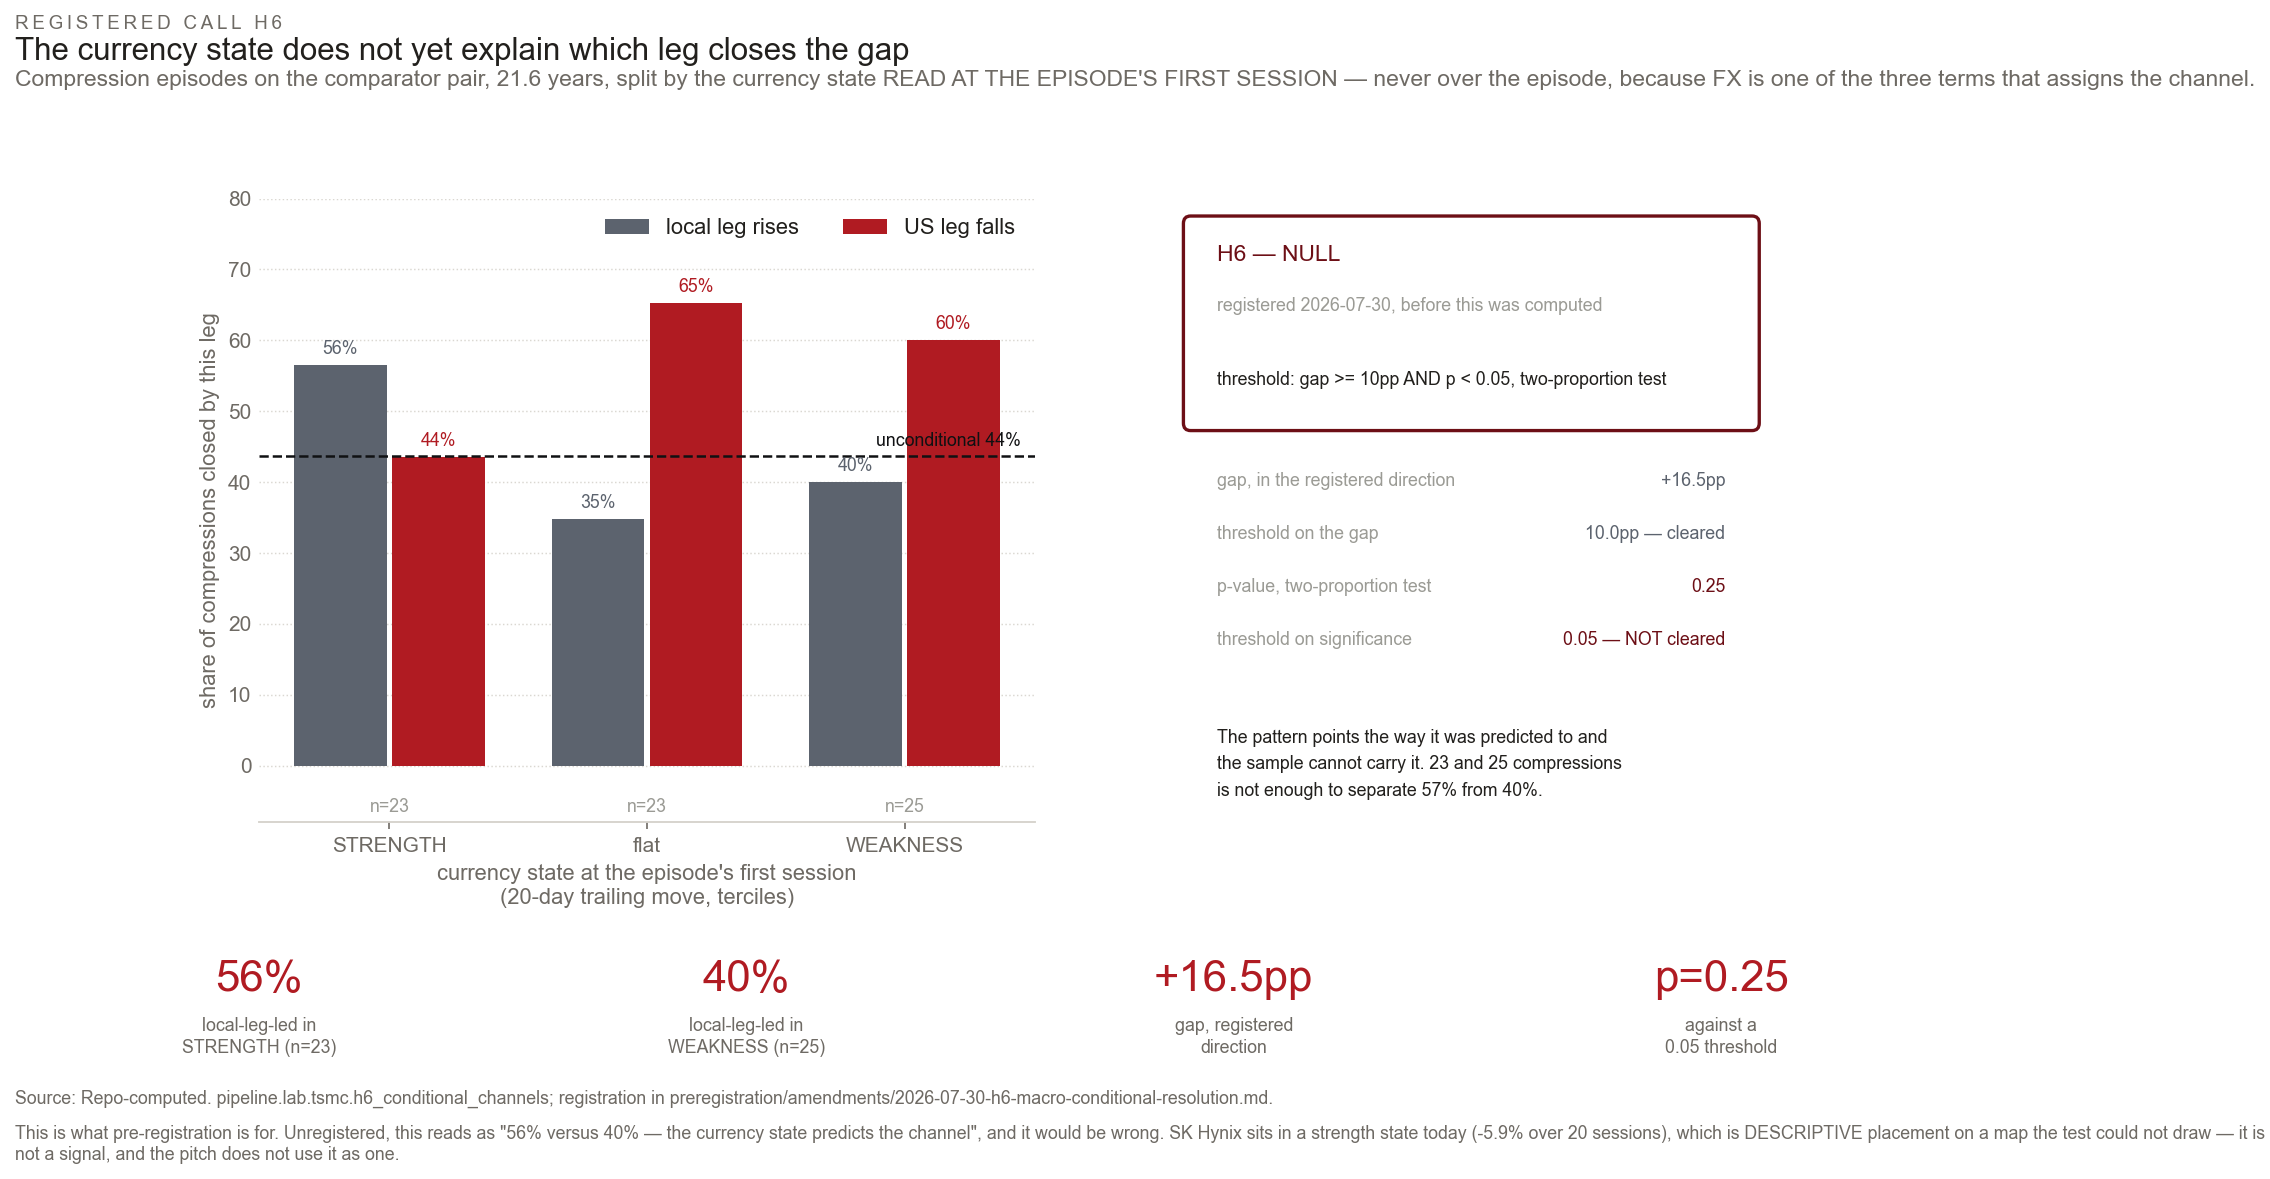

In [5]:
t = LAB.h6_conditional_channels(); v = LAB.h6_verdict(t); s = LAB.h6_skhy_descriptive()
fig, _ = figures.g30_macro_catalyst_map(t, v, s)
fig;

**Why this is worth a slide anyway.** Unregistered, this reads as *"57% versus 40% — the
currency state predicts which leg closes the gap"*, and it would have been the headline of this
chapter. It is a coin-flip-grade separation on 23 and 25 observations wearing a conclusion's
clothes. The direction was frozen in a commit containing no numbers; the commit carrying the
numbers came after it. Anyone can check the order.

**What it does not license.** SK Hynix sits in a won-strength state today (KRW +5.9% over 20
sessions). That is descriptive placement on a map the test could not draw, and the pitch does
not use it as a signal.

## 5. The feasibility layer — three dated facts that make the trade possible at all

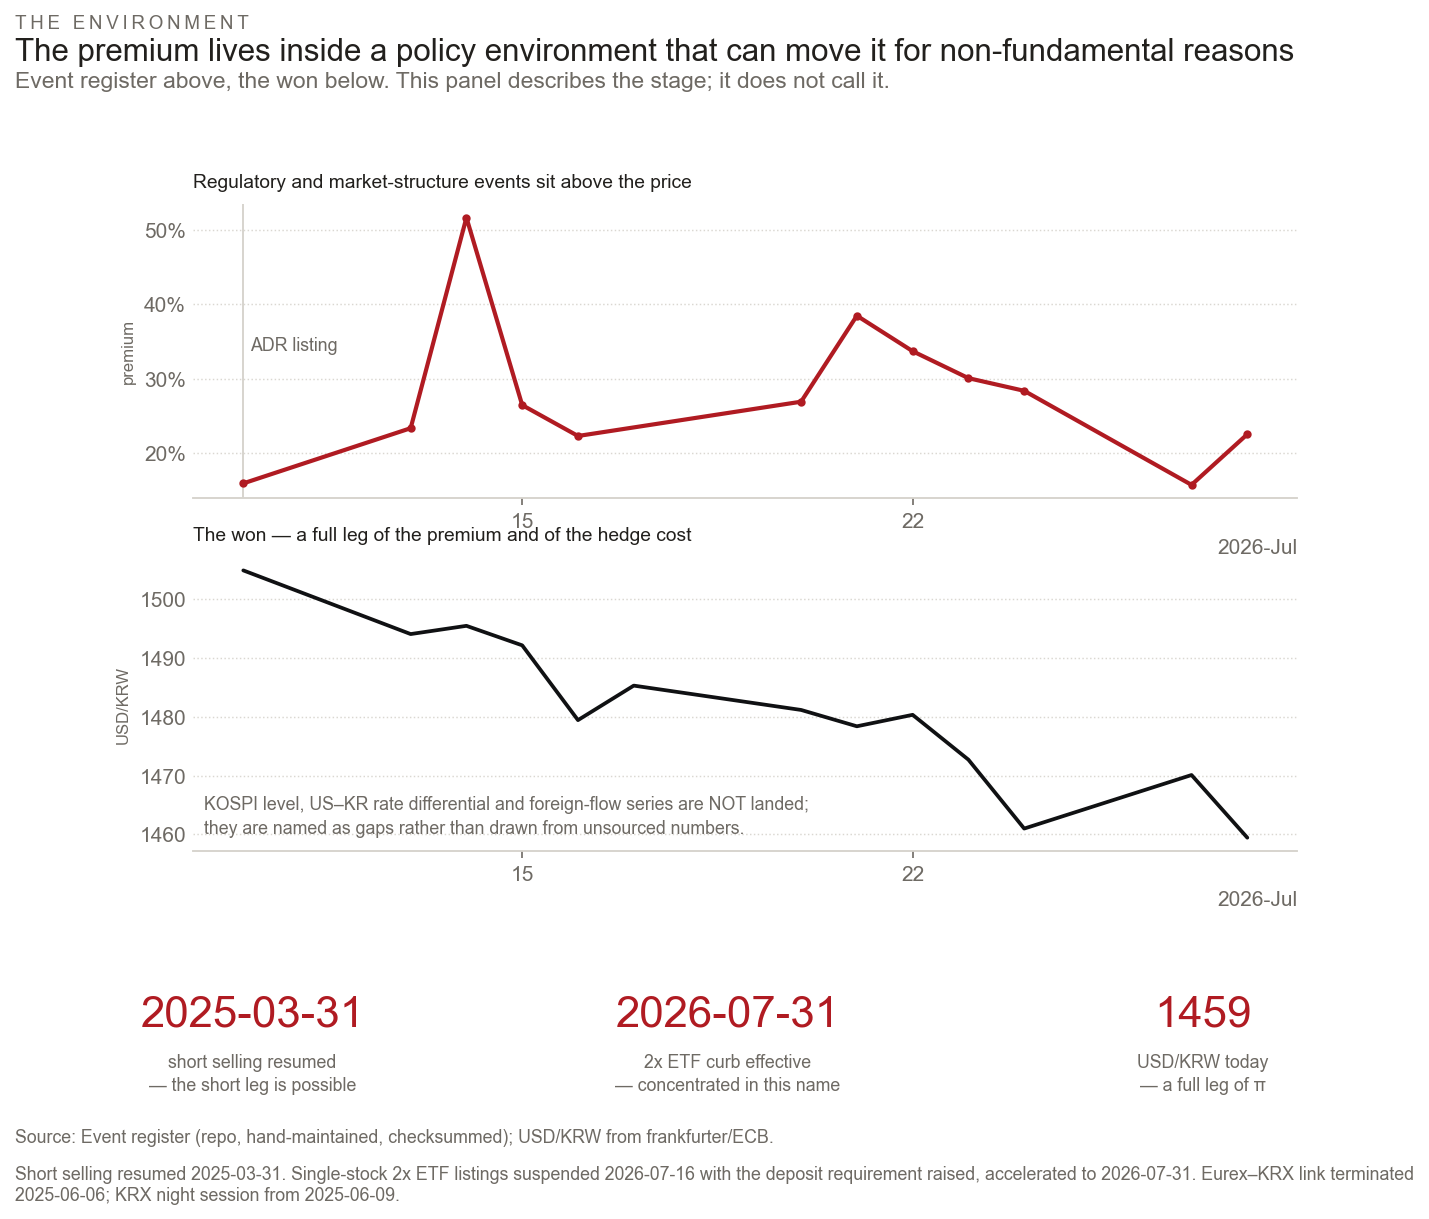

In [6]:
fig, _ = PANELS["P0a_the_stage"]()
fig;

- **Short selling resumed 2025-03-31**, all listed stocks. Without it the short leg does not
  exist and there is no trade to pitch.
- **Single-stock 2× ETF listings suspended 2026-07-16**, deposit requirement accelerated to
  **2026-07-31**; eligibility admits two names and this one is in scope. A flow event specific
  to this underlying.
- **The Eurex–KRX link terminated 2025-06-06**; KRX has run its own night session since
  **2025-06-09**. The overnight hedging route changed, and the synthetic contemporaneous
  premium depends on which session is available.

These are not colour. Each one is a precondition: the first makes the structure possible, the
second is a dated flow, the third determines how the position can be hedged overnight.

## 6. The currents, and the one thing this layer still cannot show

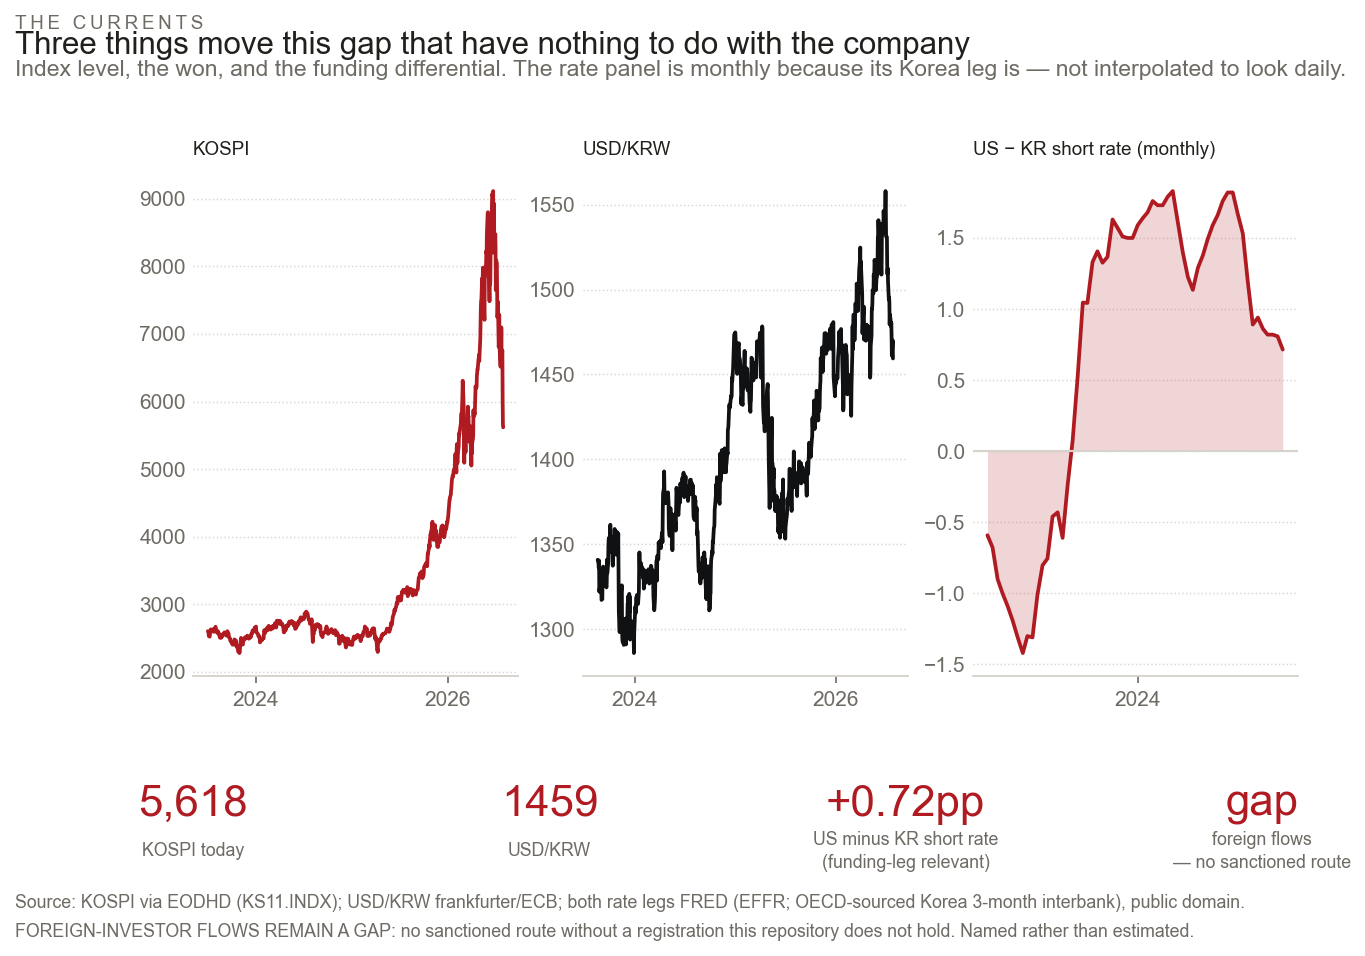

In [7]:
fig, _ = PANELS["P0b_the_currents"]()
fig;

**Foreign-investor flows remain a named gap.** The sanctioned route returns HTTP 401 without a
service-key registration this repository does not hold. The panel says so rather than
estimating a direction — a flow chart drawn from an unsourced estimate would be the single
most quotable and least defensible object in the whole project.

---

### What the macro layer entitles the pitch to say

Three sentences, and no more than three.

1. **The bid is real and the supply cannot answer it** — an ADR trading $8.8bn a day after
   twelve sessions against a decade-old local line at $8.3bn.
2. **The cost of holding it is Fed-sensitive and points the friendly way** — 2.1bp/month per
   25bp, and a hike makes it cheaper.
3. **The won moves the level a little and does not demonstrably select the channel** — 0.86
   points per 1%, 1.3% of daily variance, and a registered null on the conditional.

What the macro layer does **not** entitle anyone to say is that the won's current strength
argues for the trade. It was tested. It did not clear.